In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Librarii incarcate cu succes!")

Librarii incarcate cu succes!


In [2]:
df = pd.read_csv('../data/sp500_stocks.csv')

print("Shape:", df.shape)
print("\nPrimele 5 randuri:")
df.head()

Shape: (1891536, 8)

Primele 5 randuri:


,Date,Symbol,Adj Close,Close,High,Low,Open,Volume
0,2010-01-04,MMM,NaN,NaN,NaN,NaN,NaN,NaN
1,2010-01-05,MMM,NaN,NaN,NaN,NaN,NaN,NaN
2,2010-01-06,MMM,NaN,NaN,NaN,NaN,NaN,NaN
3,2010-01-07,MMM,NaN,NaN,NaN,NaN,NaN,NaN
4,2010-01-08,MMM,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
print("Coloane:", df.columns.tolist())
print("\nTipuri de date:")
print(df.dtypes)
print("\nValori lipsa:")
print(df.isnull().sum())

Coloane: ['Date', 'Symbol', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']

Tipuri de date:
Date          object
Symbol        object
Adj Close    float64
Close        float64
High         float64
Low          float64
Open         float64
Volume       float64
dtype: object

Valori lipsa:


Date               0
Symbol             0
Adj Close    1273705
Close        1273705
High         1273705
Low          1273705
Open         1273705
Volume       1273705
dtype: int64


In [4]:
# Eliminam ramdurile cu valori lipsa 
df = df.dropna()

# Convertim Date din string in data calendaristica
df['Date'] = pd.to_datetime(df['Date'])

# Verificam rezultatul
print("Shape dupa curatare:", df.shape)
print("Tipuri de date acum:")
print(df.dtypes)

Shape dupa curatare: (617831, 8)
Tipuri de date acum:
Date         datetime64[ns]
Symbol               object
Adj Close           float64
Close               float64
High                float64
Low                 float64
Open                float64
Volume              float64
dtype: object


In [5]:
# Filtram doar 5 companii mari
simboluri = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA']

df_top = df[df['Symbol'].isin(simboluri)]

print("Randuri selectate:", df_top.shape[0])
print(df_top['Symbol'].value_counts())

Randuri selectate: 11182
Symbol
AMZN    3768
MSFT    3768
TSLA    3646
Name: count, dtype: int64


In [6]:
df_top = df_top.sort_values(['Symbol', 'Date'])
df_top = df_top.reset_index(drop=True)

print("Primele 5 randuri:")
df_top.head()

Primele 5 randuri:


,Date,Symbol,Adj Close,Close,High,Low,Open,Volume
0,2010-01-04,AMZN,6.6950,6.6950,6.8305,6.6570,6.8125,151998000.0
1,2010-01-05,AMZN,6.7345,6.7345,6.7740,6.5905,6.6715,177038000.0
2,2010-01-06,AMZN,6.6125,6.6125,6.7365,6.5825,6.7300,143576000.0
3,2010-01-07,AMZN,6.5000,6.5000,6.6160,6.4400,6.6005,220604000.0
4,2010-01-08,AMZN,6.6760,6.6760,6.6840,6.4515,6.5280,196610000.0


In [7]:
# Reincarcam fisierul curat 
df = pd.read_csv('../data/sp500_stocks.csv')
df['Date'] = pd.to_datetime(df['Date'])

# Filtram cele 5 companii INAINTE de dropna
simboluri = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA']
df_top = df[df['Symbol'].isin(simboluri)].copy()

# Acum eliminam NaN
df_top = df_top.dropna(subset=['Close', 'Open', 'High', 'Low', 'Volume'])

# Sortam
df_top = df_top.sort_values(['Symbol', 'Date']).reset_index(drop=True)


print("Shape final:", df_top.shape)

print("\nValori lipsa:")
print(df_top.isnull().sum())
print("\nPrimele 5 randuri:")
df_top.head()

Shape final: (11182, 8)

Valori lipsa:
Date         0
Symbol       0
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64

Primele 5 randuri:


,Date,Symbol,Adj Close,Close,High,Low,Open,Volume
0,2010-01-04,AMZN,6.6950,6.6950,6.8305,6.6570,6.8125,151998000.0
1,2010-01-05,AMZN,6.7345,6.7345,6.7740,6.5905,6.6715,177038000.0
2,2010-01-06,AMZN,6.6125,6.6125,6.7365,6.5825,6.7300,143576000.0
3,2010-01-07,AMZN,6.5000,6.5000,6.6160,6.4400,6.6005,220604000.0
4,2010-01-08,AMZN,6.6760,6.6760,6.6840,6.4515,6.5280,196610000.0


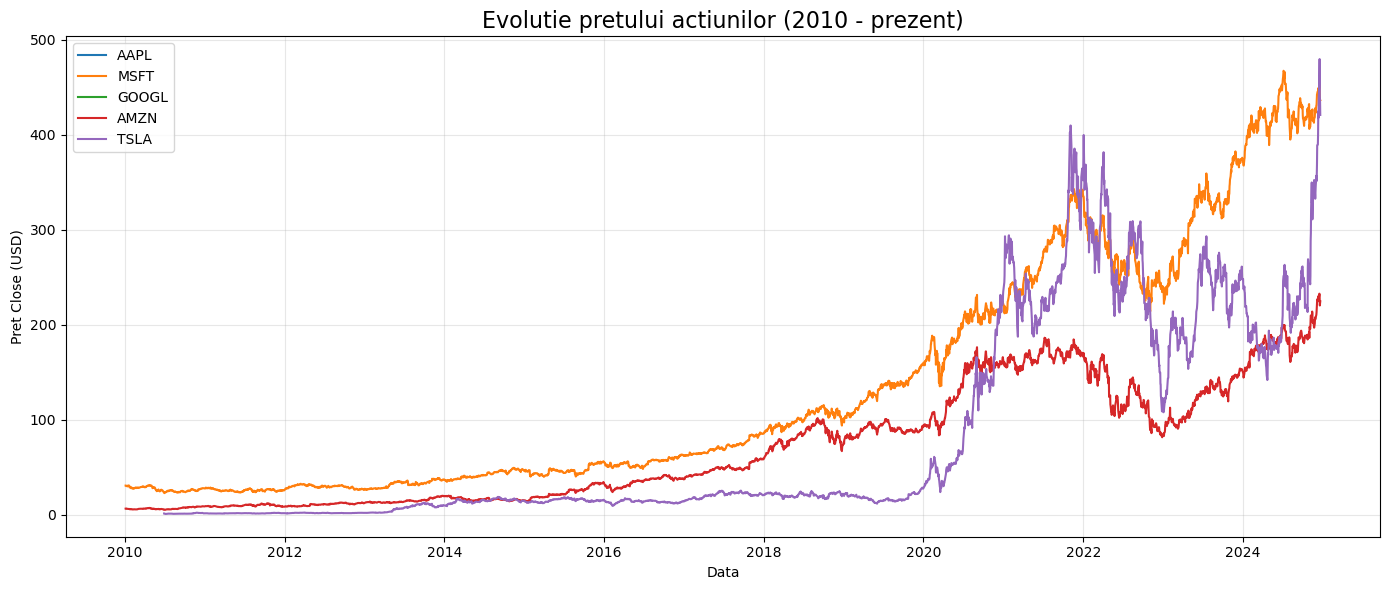

Grafic salvat in reports/


In [8]:
plt.figure(figsize=(14, 6))

for simbol in simboluri:
    date_simbol = df_top[df_top['Symbol'] == simbol]
    plt.plot(date_simbol['Date'], date_simbol['Close'], label=simbol)

plt.title('Evolutie pretului actiunilor (2010 - prezent)', fontsize=16)
plt.xlabel('Data')
plt.ylabel('Pret Close (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/evolutie_preturi.png', dpi=150)
plt.show()

print("Grafic salvat in reports/")

In [9]:
stats = df_top.groupby('Symbol')['Close'].agg([
    ('Pret Minim', 'min'),
    ('Pret Maxim', 'max'),
    ('Pret Mediu', 'mean'),
    ('Ultima Valoare', 'last')
]).round(2)

print("Statistice per companie:")
stats

Statistice per companie:


,Pret Minim,Pret Maxim,Pret Mediu,Ultima Valoare
Symbol,,,,
AMZN,5.43,232.93,71.20,224.92
MSFT,23.01,467.56,135.19,436.60
TSLA,1.05,479.86,80.95,421.06


In [10]:
# Calculam randamentul zilnic procentual
df_top['Daily Return'] = df_top.groupby('Symbol')['Close'].pct_change() * 100

print("Randament zilnic adaugat ")
df_top[['Date', 'Symbol', 'Close', 'Daily Return']].head(10)

Randament zilnic adaugat 


,Date,Symbol,Close,Daily Return
0,2010-01-04,AMZN,6.6950,NaN
1,2010-01-05,AMZN,6.7345,0.589989
2,2010-01-06,AMZN,6.6125,-1.811563
3,2010-01-07,AMZN,6.5000,-1.701326
4,2010-01-08,AMZN,6.6760,2.707694
5,2010-01-11,AMZN,6.5155,-2.404135
6,2010-01-12,AMZN,6.3675,-2.271510
7,2010-01-13,AMZN,6.4555,1.382023
8,2010-01-14,AMZN,6.3675,-1.363183
9,2010-01-15,AMZN,6.3570,-0.164899


Volatilitate (risc) per companie %:
Symbol
TSLA    3.61
AMZN    2.06
MSFT    1.61
Name: Daily Return, dtype: float64


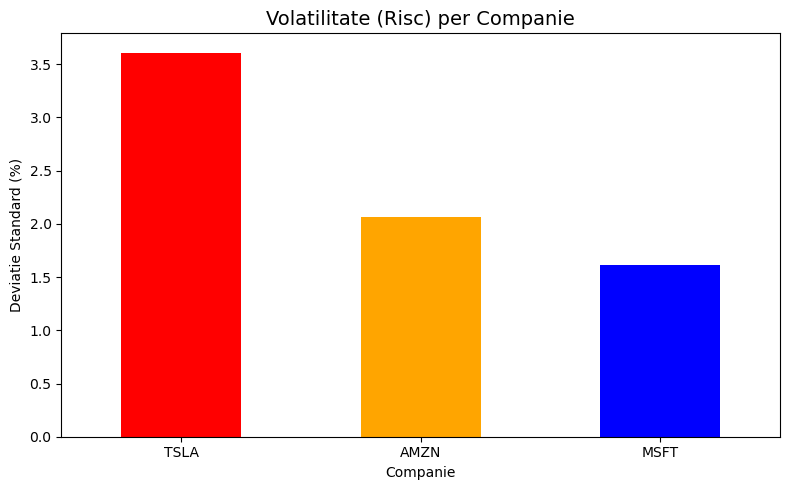

In [11]:
volatilitate = df_top.groupby('Symbol')['Daily Return'].std().round(2)
volatilitate = volatilitate.sort_values(ascending=False)

print("Volatilitate (risc) per companie %:")
print(volatilitate)

# Grafic volatilitate
plt.figure(figsize=(8, 5))
volatilitate.plot(kind='bar', color=['red', 'orange','blue','green','purple'])
plt.title('Volatilitate (Risc) per Companie', fontsize=14)
plt.xlabel('Companie')
plt.ylabel('Deviatie Standard (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../reports/volatilitate.png', dpi=150)
plt.show()

In [19]:
randament_total = (
    df_top.groupby('Symbol', group_keys=False)['Close']
    .apply(lambda x: (x.iloc[-1] / x.iloc[0] - 1) * 100)
    .round(2)
    .sort_values(ascending=False)
)

print("Randament total 2010-prezent (%):")
print(randament_total)

Randament total 2010-prezent (%):
Symbol
TSLA    26337.42
AMZN     3259.52
MSFT     1310.66
Name: Close, dtype: float64


In [21]:
# Exportam dataframe-ul curat pentru Power BI
df_top.to_csv('../data/date_curate_powerbi.csv', index=False)

# Exportam si statisticile
stats_complete = df_top.groupby('Symbol')['Close'].agg([
    ('Pret Minim', 'min'),
    ('Pret Maxim', 'max'),
    ('Pret Mediu', 'mean'),
    ('Ultima Valoare', 'last')
]).round(2)

stats_complete['Randament Total %'] = randament_total
stats_complete['Volatilitate %'] = df_top.groupby('Symbol')['Daily Return'].std().round(2)

print("Fisiere exportate pentru Power BI ")
print("1. data/date_curate_powerbi.csv")
print("2, data/statistici_companii.csv")

Fisiere exportate pentru Power BI 
1. data/date_curate_powerbi.csv
2, data/statistici_companii.csv
